# Master BigData UCM 2024_25

## 1. Datos vehículos a la venta 2016 en UK

Propósito:

- Generar un treemap interactivo usando la librería plotly



In [1]:
import pandas as pd

import plotly.express as px

### Carga de datos

Este dataset tiene ya 7 años pero sigue siendo válido para nuestro propósito. 

La principal ventaja es que tiene una variale de grupo (o "factor") creada en español (la variable "Tipo") para facilitar los gráficos por tipo de vehículo.

In [2]:
df= pd.read_pickle("datos_vehiculos_2016.pkl")

In [3]:
df.shape

(4490, 20)

In [4]:
df.describe(include = 'all')

,Manufacturer,Model,EngineCapacity,FuelType,MetricUrbanCold,MetricExtraUrban,MetricCombined,ImperialUrbanCold,ImperialExtraUrban,ImperialCombined,CO2gkm,FuelCost12000Miles,EuroStandard,NoiseLeveldBA,EmissionsCOmgkm,THCEmissionsmgkm,EmissionsNOxmgkm,THC+NOxEmissionsmgkm,ParticulatesNo_mgkm,Tipo
count,4490,4490,4490.000000,4490,4459.000000,4459.000000,4490.000000,4459.000000,4459.000000,4490.000000,4490.000000,4490.000000,4490.0,4490.000000,4490.000000,2230.000000,4490.000000,2289.000000,2293.000000,4490
unique,44,450,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,BMW,Coupe,NaN,Diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Diesel
freq,607,260,NaN,2274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2274
mean,NaN,NaN,1991.111804,NaN,6.925252,4.790491,5.549042,45.364230,62.014891,55.120445,135.823163,1086.980401,6.0,71.302249,260.113007,41.636726,37.138886,80.458934,0.300039,NaN
std,NaN,NaN,828.057573,NaN,2.800404,1.224893,1.794549,12.962089,12.771535,15.869631,39.732306,348.519954,0.0,1.969812,143.096498,14.819350,18.805169,22.962894,0.331194,NaN
min,NaN,NaN,647.000000,NaN,0.000000,0.000000,0.600000,0.000000,0.000000,17.300000,13.000000,117.000000,6.0,66.000000,10.000000,4.000000,1.000000,19.000000,0.000000,NaN
25%,NaN,NaN,1499.000000,NaN,5.200000,4.000000,4.400000,36.700000,53.300000,46.300000,112.000000,867.000000,6.0,70.000000,156.000000,33.000000,23.000000,66.000000,0.060000,NaN
50%,NaN,NaN,1968.000000,NaN,6.100000,4.500000,5.100000,46.300000,62.800000,55.400000,127.000000,999.500000,6.0,71.000000,230.000000,41.000000,36.000000,81.000000,0.180000,NaN
75%,NaN,NaN,1997.000000,NaN,7.700000,5.300000,6.100000,54.300000,70.600000,64.200000,149.000000,1202.000000,6.0,73.000000,329.000000,49.000000,52.000000,97.000000,0.480000,NaN


In [5]:
count_tipo = df['Tipo'].value_counts(sort = True)
count_tipo

Tipo
Diesel      2274
Gasolina    2095
HEV          121
Name: count, dtype: int64

In [6]:
count_manufacturer = df['Manufacturer'].value_counts(sort = True)
count_manufacturer

Manufacturer
BMW                     607
AUDI                    514
MERCEDES-BENZ           436
FORD                    362
VOLKSWAGEN              340
SKODA                   223
VAUXHALL                206
MINI                    167
KIA                     152
SEAT                    126
VOLVO                   120
PORSCHE                 101
PEUGEOT                  99
TOYOTA                   95
RENAULT                  86
VOLKSWAGEN C.V.          83
CITROEN                  78
LEXUS                    54
NISSAN                   53
CHRYSLER JEEP            50
FIAT                     49
HYUNDAI                  49
DS                       46
MAZDA                    40
JAGUAR                   38
INFINITI                 37
HONDA                    35
SSANGYONG                33
LAND ROVER               26
SUZUKI                   24
SUBARU                   22
McLaren                  18
SMART                    16
BENTLEY MOTORS           15
ALFA ROMEO               14
DACIA  

# Preparación de tabla para treemap

In [7]:
para_treemap = df[["Manufacturer", 
                   "Tipo"]].value_counts()

In [8]:
para_treemap

Manufacturer         Tipo    
BMW                  Diesel      333
AUDI                 Diesel      298
BMW                  Gasolina    261
FORD                 Diesel      216
MERCEDES-BENZ        Diesel      214
                                ... 
PORSCHE              HEV           2
DS                   HEV           1
LAND ROVER           HEV           1
LONDON TAXI COMPANY  Diesel        1
MITSUBISHI           HEV           1
Name: count, Length: 90, dtype: int64

In [9]:
para_tree2 = para_treemap.reset_index(name = "count")

In [10]:
para_tree2

,Manufacturer,Tipo,count
0,BMW,Diesel,333
1,AUDI,Diesel,298
2,BMW,Gasolina,261
3,FORD,Diesel,216
4,MERCEDES-BENZ,Diesel,214
...,...,...,...
85,PORSCHE,HEV,2
86,DS,HEV,1
87,LAND ROVER,HEV,1
88,LONDON TAXI COMPANY,Diesel,1


In [11]:
para_tree2.dtypes

Manufacturer      str
Tipo              str
count           int64
dtype: object

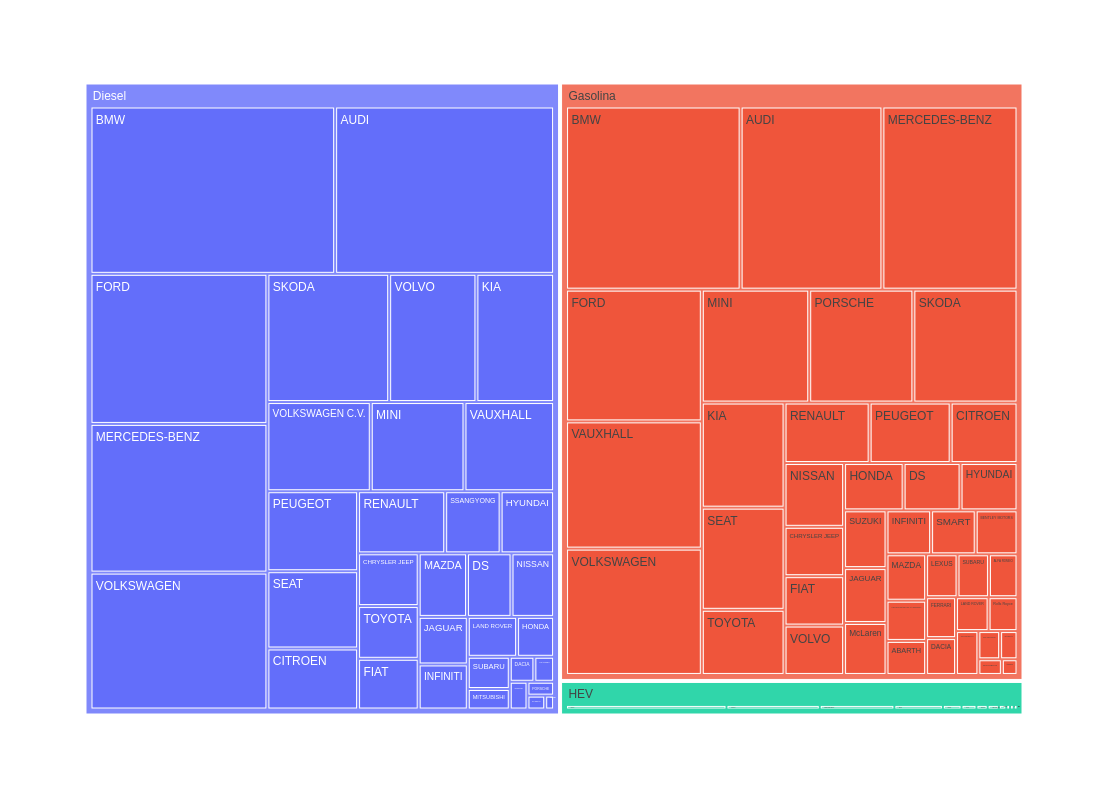

In [12]:
# plot it
fig = px.treemap(para_tree2, 
                 path = ['Tipo', 'Manufacturer'],
                 values = 'count',
                width = 1000,
                height = 800)

fig.show()

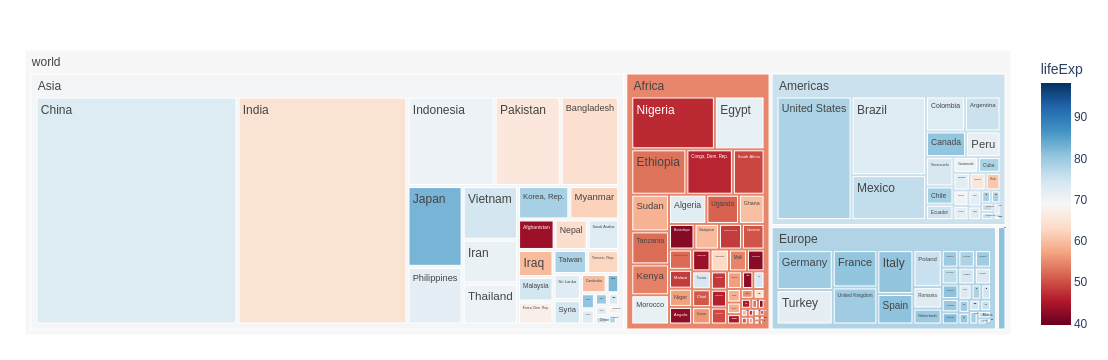

In [13]:
import numpy as np
df = px.data.gapminder().query("year == 2007")
fig = px.treemap(df, 
                 path = [px.Constant("world"), 'continent', 'country'], 
                 values = 'pop',
                 color = 'lifeExp', 
                 hover_data = ['iso_alpha'],
                 color_continuous_scale = 'RdBu',
                 color_continuous_midpoint = np.average(df['lifeExp'], weights=df['pop']))
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

In [14]:
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


Buscamos una escala de color para nuestro propósito.

Lista completa aquí:

https://matplotlib.org/stable/gallery/color/colormap_reference.html

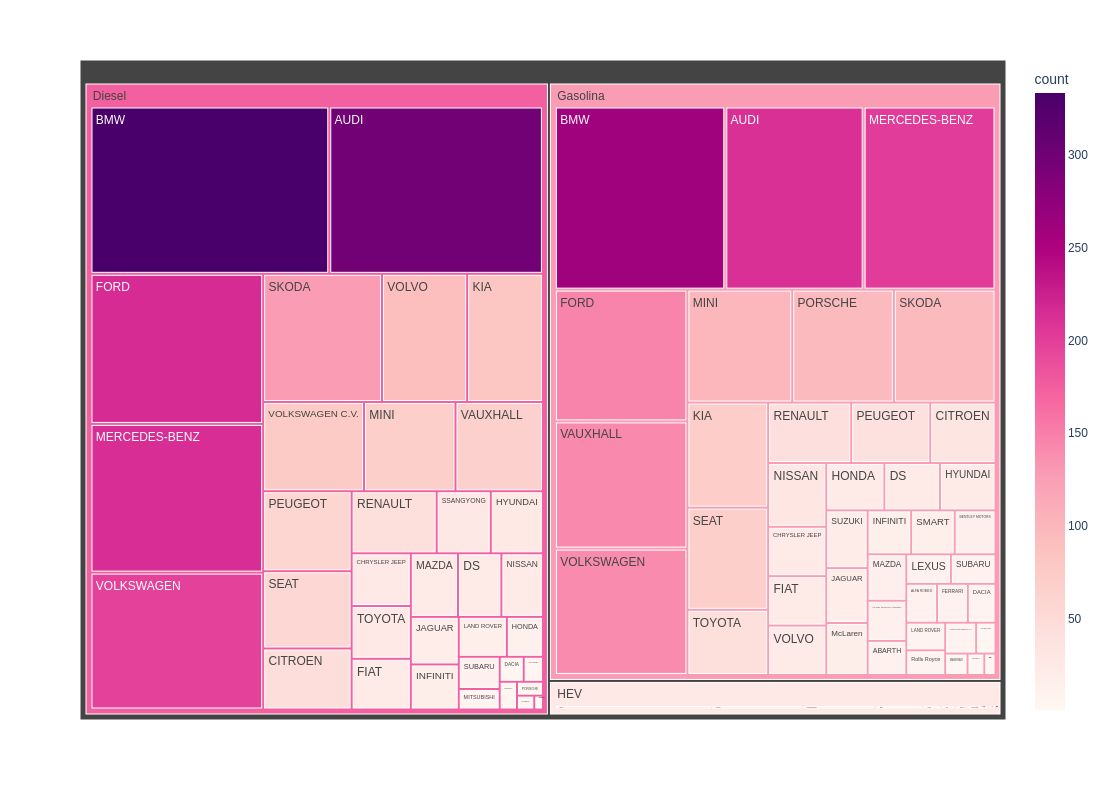

In [15]:
# plot it
fig = px.treemap(para_tree2, 
                 path = ['Tipo', 'Manufacturer'],
                 values = 'count',
                 color='count',
                 color_continuous_scale='RdPu',
                 width = 1000,
                 height = 800)

fig.show()

In [16]:
fig.write_html("my_treemap.html")